# Replicating Mishu (2025): *Forecasting Volatility of Bitcoin*
### A from-scratch, faithful implementation of the thesis's HAR / HAR-RV-J / HAR-BV-J / Random Forest methodology

**What this notebook is.** A comparison against an external thesis (Taslima Rahman Mishu, Masaryk University, 2025) reported much higher out-of-sample R² (≈0.20-0.45, depending on horizon) than this project's own kept model (0.24 historical / 0.18 live, at a 7-day/168-hour horizon). Rather than guess why, this notebook implements the thesis's own models exactly as it specifies them - same formulas, same rolling-window discipline, same evaluation metrics - and runs them on data as close to the thesis's own as this project's infrastructure allows. The goal is to see how much of the reported gap survives an honest, like-for-like replication, and how much comes from methodological choices (shorter horizons, a log-variance target, daily-only sampling, winsorization) already flagged as differences when the thesis was first compared to the main notebook's own Check 17.

**Two unavoidable divergences from the thesis, both resolved as directly as possible and flagged again at the point each one matters:**
- **Data source and period.** The thesis uses CoinMarketCap data from January 2015 through March 2025. This project's entire infrastructure is built on Binance via CCXT (see the main notebook's own Data Overview section for why - CoinMarketCap aggregates multiple exchanges and its full history requires a paid API tier; more fundamentally, Binance itself did not exist before August 2017, so no exchange-native fetch can reach back to 2015 regardless of API access). This notebook reuses the main project's own cached hourly OHLCV (`data/btc_hourly_ohlcv.csv`, already fetched via CCXT), resampled to daily candles - so the sample here runs **2017-08-17 through today**, about 7.5 years, not the thesis's ~10.
- **A handful of details the thesis states ambiguously** - exactly how zero-valued jump variation should be log-transformed, Random Forest's precise input feature set, and how many lags Newey-West HAC standard errors should use - are resolved with the most literal, defensible reading of the thesis's own text. Each is flagged inline, at the point the choice is made, not buried here.

**What is implemented exactly as specified:** the Garman-Klass realized-variance estimator, the thesis's own (non-standard) single-lag bipower-variation formula, jump variation as the non-negative RV−BV residual, winsorization at the 0.5%/99.5% levels, log-transformation of the target and regressors, the HAR/HAR-RV-J/HAR-BV-J cascade specifications, a genuine walk-forward rolling window of 1,000 observations re-estimated at every step (not once and reused), and Random Forest as a fourth, non-linear comparison - across the same three forecast horizons (1-day, 5-day, 22-day).

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

ROLLING_WINDOW_OBS = 1000     # Corsi (2009)-style rolling window, per the thesis's own out-of-sample design (Sec 3.6.5)
HORIZONS = [1, 5, 22]          # 1-day, 5-day, 22-day ahead - the thesis's three forecast horizons
WINSOR_LOWER, WINSOR_UPPER = 0.005, 0.995   # 0.5% / 99.5%, per the thesis's Data Processing section (Sec 3.4)
NW_LAGS = 5                    # Newey-West HAC lag length - not stated explicitly in the thesis; 5 is the
                                # conventional default for daily financial data (~1 trading week) and matches
                                # the same horizon this project's own HAR-RV-X uses for its own 'week' component
print('Setup complete.')

Setup complete.


## 1. Data
Resamples this project's own cached hourly BTC/USDT OHLCV (Binance via CCXT) to daily candles - Open/High/Low/Close/Volume aggregate exactly from complete hourly bars, so this is identical to a native daily fetch over the same window, not an approximation. See the note above on why the resulting sample period (2017-08-17 onward) differs from the thesis's own 2015-2025.

In [2]:
df_hourly = pd.read_csv('data/btc_hourly_ohlcv.csv', parse_dates=['Date']).sort_values('Date').set_index('Date')

df_daily = df_hourly.resample('1D').agg({
    'Open': 'first', 'High': 'max', 'Low': 'min', 'Close': 'last', 'Volume': 'sum'
}).dropna().reset_index()

print(f'Daily candles: {len(df_daily):,} ({df_daily["Date"].min().date()} to {df_daily["Date"].max().date()})')
print(f"(Thesis's own sample: 2015-01 to 2025-03, ~3,700 days. This one is shorter for the reason noted above.)")
df_daily.head()

Daily candles: 3,059 (2017-08-17 to 2025-12-31)
(Thesis's own sample: 2015-01 to 2025-03, ~3,700 days. This one is shorter for the reason noted above.)


,Date,Open,High,Low,Close,Volume
0,2017-08-17,4261.48,4485.39,4200.74,4285.08,795.150377
1,2017-08-18,4285.08,4371.52,3938.77,4108.37,1199.888264
2,2017-08-19,4108.37,4184.69,3850.00,4139.98,381.309763
3,2017-08-20,4120.98,4211.08,4032.62,4086.29,467.083022
4,2017-08-21,4069.13,4119.62,3911.79,4016.00,691.743060


## 2. Volatility Measures: Garman-Klass RV, Bipower Variation, Jump Variation
Implements the thesis's own formulas exactly (Sections 3.5-3.6.2):

$$RV_t = 0.5 \cdot \left[\ln\left(\frac{High_t}{Low_t}\right)\right]^2 - (2\ln 2 - 1) \cdot \left[\ln\left(\frac{Close_t}{Open_t}\right)\right]^2$$

the Garman & Klass (1980) range-based daily variance estimator - the thesis's own "Realized Variance," despite the name, is a single-day OHLC estimate, not a sum of many intraday squared returns.

$$R_t = \ln(High_t) - \ln(Low_t) \quad \text{(the log-range - not a return - used as bipower variation's input, per the thesis's own Section 3.6.3)}$$
$$BV_t = \frac{2}{\pi} \cdot |R_t| \cdot |R_{t-1}|$$
$$JV_t = \max(RV_t - BV_t,\ 0)$$

**This BV formula is a genuine, non-standard departure from Barndorff-Nielsen and Shephard's original bipower variation**, which is defined over many high-frequency intraday returns within a day, not a single daily log-range value multiplied by its own one-day lag. The thesis's own Section 8 (Limitations) explicitly acknowledges relying on "daily Garman-Klass estimators" rather than true intraday data for exactly this reason. Implemented here precisely as the thesis specifies it, not as the textbook version - the goal is replication, not correction.

In [3]:
O, H, L, C = df_daily['Open'], df_daily['High'], df_daily['Low'], df_daily['Close']

RV = 0.5 * np.log(H / L) ** 2 - (2 * np.log(2) - 1) * np.log(C / O) ** 2
R = np.log(H) - np.log(L)   # log-range - the thesis's own input to BV, not a return

df_daily['RV'] = RV
df_daily['R'] = R
df_daily['BV'] = (2 / np.pi) * R.abs() * R.shift(1).abs()
df_daily['JV'] = (df_daily['RV'] - df_daily['BV']).clip(lower=0)

print(f'Negative RV values (should be ~0 - GK variance is provably non-negative under normal OHLC ordering): '
      f'{(df_daily["RV"] < 0).sum()}')
print(f'Days with JV == 0 (RV <= BV): {(df_daily["JV"] == 0).sum():,} of {len(df_daily):,} '
      f'({(df_daily["JV"]==0).mean()*100:.1f}%) - handled explicitly in the next section.')
df_daily[['RV', 'BV', 'JV']].describe()

Negative RV values (should be ~0 - GK variance is provably non-negative under normal OHLC ordering): 0
Days with JV == 0 (RV <= BV): 2,424 of 3,059 (79.2%) - handled explicitly in the next section.


,RV,BV,JV
count,3059.000000,3058.000000,3058.000000
mean,0.001601,0.002204,0.000226
std,0.004088,0.004940,0.001846
min,0.000006,0.000015,0.000000
25%,0.000286,0.000493,0.000000
50%,0.000657,0.001064,0.000000
75%,0.001414,0.002204,0.000000
max,0.094304,0.170888,0.058386


## 3. Winsorization, Log-Transform, and HAR-Style Lagged Features
Per Section 3.4 (Data Processing): RV and JV are winsorized at the 0.5%/99.5% levels, *then* log-transformed - in that order, matching the thesis's own described sequence. BV is left unwinsorized, since the thesis's own text names only RV and JV for that step. Winsorization here uses **full-sample** quantiles (computed once, over the whole series) - a mild look-ahead simplification, but exactly what the thesis itself describes doing (a general "Data Processing" step applied before any modeling, not a rolling or expanding one), so it is kept as-is for a faithful replication rather than silently tightened to this project's own, stricter no-lookahead standard used everywhere else.

`log(JV)` is undefined whenever `JV = 0`, which the check above shows happens often - unsurprising for a jump measure built from a single-lag bipower estimator this simple. The thesis does not specify how it handled this. A small constant is added before logging (`log(JV + 1e-6)`), the standard fix in this literature for a naturally zero-heavy jump series (e.g. Andersen, Bollerslev & Diebold, 2007).

In [4]:
def winsorize(s, lower=WINSOR_LOWER, upper=WINSOR_UPPER):
    lo, hi = s.quantile(lower), s.quantile(upper)
    return s.clip(lower=lo, upper=hi)

df_daily['RV_w'] = winsorize(df_daily['RV'])
df_daily['JV_w'] = winsorize(df_daily['JV'])

print(f'RV_w min after winsorizing: {df_daily["RV_w"].min():.8f} (must be > 0 for log() to be defined)')

JUMP_EPS = 1e-6
df_daily['ln_RV'] = np.log(df_daily['RV_w'])
df_daily['ln_BV'] = np.log(df_daily['BV'])
df_daily['ln_JV'] = np.log(df_daily['JV_w'] + JUMP_EPS)

# HAR cascade: daily = today's own log-RV; weekly/monthly = trailing averages of log-RV (the thesis's own
# wording - 'several lagged versions of this log-realized variance... 5-day average... 22-day average' -
# describes averaging AFTER the log transform, matching Corsi's (2009) own convention).
df_daily['RV_day'] = df_daily['ln_RV']
df_daily['RV_week'] = df_daily['ln_RV'].rolling(5).mean()
df_daily['RV_month'] = df_daily['ln_RV'].rolling(22).mean()
df_daily['BV_day'] = df_daily['ln_BV']
df_daily['JV_day'] = df_daily['ln_JV']

# Targets: log(RV) realized h days ahead - a single day's value, not a cumulative window (unlike this
# project's own volatility_7d target - see the Discussion at the end for what this structural difference means).
for h in HORIZONS:
    df_daily[f'target_h{h}'] = df_daily['ln_RV'].shift(-h)

har_cols = ['RV_day', 'RV_week', 'RV_month']
harj_cols = ['RV_day', 'RV_week', 'RV_month', 'JV_day']
harbvj_cols = ['BV_day', 'RV_week', 'RV_month', 'JV_day']

print(f'\nModel-ready rows (after warm-up NaNs): {df_daily.dropna(subset=harj_cols).shape[0]:,}')

RV_w min after winsorizing: 0.00002013 (must be > 0 for log() to be defined)

Model-ready rows (after warm-up NaNs): 3,038


## 4. In-Sample Estimation (Section 3.6.4)
Estimates HAR, HAR-RV-J, and HAR-BV-J by OLS on the **full sample**, with Newey-West (HAC) standard errors to correct for the heteroskedasticity and autocorrelation the thesis's own Section 3.6.5 names explicitly. One fit per model per horizon - this is the in-sample fit quality check the thesis itself reports before ever going out-of-sample.

In [5]:
def fit_ols_hac(y, X, maxlags=NW_LAGS):
    Xc = sm.add_constant(X)
    valid = Xc.notna().all(axis=1) & y.notna()
    model = sm.OLS(y[valid], Xc[valid])
    return model.fit(cov_type='HAC', cov_kwds={'maxlags': maxlags})

model_specs = {'HAR': har_cols, 'HAR-RV-J': harj_cols, 'HAR-BV-J': harbvj_cols}
in_sample_results = {}

for h in HORIZONS:
    y = df_daily[f'target_h{h}']
    for name, cols in model_specs.items():
        res = fit_ols_hac(y, df_daily[cols])
        in_sample_results[(name, h)] = res
        print(f'{name}, horizon={h}d   R2={res.rsquared:.4f}   Adj.R2={res.rsquared_adj:.4f}   n={int(res.nobs)}')
    print()

HAR, horizon=1d   R2=0.4189   Adj.R2=0.4183   n=3037
HAR-RV-J, horizon=1d   R2=0.4190   Adj.R2=0.4182   n=3037
HAR-BV-J, horizon=1d   R2=0.4162   Adj.R2=0.4155   n=3037

HAR, horizon=5d   R2=0.3194   Adj.R2=0.3187   n=3033
HAR-RV-J, horizon=5d   R2=0.3194   Adj.R2=0.3186   n=3033
HAR-BV-J, horizon=5d   R2=0.3197   Adj.R2=0.3188   n=3033

HAR, horizon=22d   R2=0.1962   Adj.R2=0.1954   n=3016
HAR-RV-J, horizon=22d   R2=0.1965   Adj.R2=0.1955   n=3016
HAR-BV-J, horizon=22d   R2=0.1934   Adj.R2=0.1923   n=3016



In [6]:
# Full regression table for the 1-day horizon (matches the level of detail the thesis's own Section 4
# reports for its in-sample results) - coefficients, Newey-West t-stats, and p-values.
for name in model_specs:
    print(f'=== {name}, 1-day horizon ===')
    print(in_sample_results[(name, 1)].summary())
    print()

=== HAR, 1-day horizon ===
                            OLS Regression Results                            
Dep. Variable:              target_h1   R-squared:                       0.419
Model:                            OLS   Adj. R-squared:                  0.418
Method:                 Least Squares   F-statistic:                     705.0
Date:                Sat, 29 Aug 2026   Prob (F-statistic):               0.00
Time:                        21:52:31   Log-Likelihood:                -4188.0
No. Observations:                3037   AIC:                             8384.
Df Residuals:                    3033   BIC:                             8408.
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.7959    

## 5. Out-of-Sample Rolling-Window Forecasting (Section 3.6.5)
A genuine walk-forward evaluation: at every point in the out-of-sample period, each model is refit on only the **trailing 1,000 observations** and used to predict the current target - never refit on data it is about to be scored against, and never reusing a single historical fit across the whole test period ("the models were re-estimated at each step"). Implemented with a direct `numpy.linalg.lstsq` solve rather than `statsmodels.OLS.fit()` inside the loop, purely for speed (thousands of refits per model/horizon combination) - the closed-form OLS solution is identical either way; only the interface differs. The final window's own fit (with proper HAC inference) is reported separately below, matching the thesis's own "coefficients... reported from the final rolling window."

In [7]:
def rolling_ols_forecast(y, X, window=ROLLING_WINDOW_OBS):
    """Walk-forward rolling-window OLS: refit on the trailing `window` rows at every step, predict
    only the current row - never using a row's own future for its own prediction. Returns predictions
    aligned to y's index (NaN wherever there isn't a full trailing window of valid history yet)."""
    n = len(X)
    Xc = np.column_stack([np.ones(n), X.values])
    yv = y.values
    valid = ~np.isnan(Xc).any(axis=1) & ~np.isnan(yv)
    preds = np.full(n, np.nan)
    for t in range(window, n):
        if not valid[t]:
            continue
        tr = slice(t - window, t)
        tr_valid = valid[tr]
        if tr_valid.sum() < window * 0.9:   # not enough real history in this window (e.g. near the very start)
            continue
        Xt, yt = Xc[tr][tr_valid], yv[tr][tr_valid]
        beta, *_ = np.linalg.lstsq(Xt, yt, rcond=None)
        preds[t] = Xc[t] @ beta
    return pd.Series(preds, index=y.index)

def evaluate(y_true, y_pred, label):
    mask = y_true.notna() & y_pred.notna()
    yt, yp = y_true[mask], y_pred[mask]
    rmse = np.sqrt(mean_squared_error(yt, yp))
    mae = mean_absolute_error(yt, yp)
    r2 = r2_score(yt, yp)
    print(f'{label:28s}  n={len(yt):5d}  RMSE={rmse:.4f}  MAE={mae:.4f}  R2={r2:.4f}')
    return {'Model': label, 'n': len(yt), 'RMSE': rmse, 'MAE': mae, 'R2': r2}

oos_results = []
oos_preds = {}
for h in HORIZONS:
    y = df_daily[f'target_h{h}']
    print(f'--- Horizon: {h} day(s) ---')
    for name, cols in model_specs.items():
        pred = rolling_ols_forecast(y, df_daily[cols])
        oos_preds[(name, h)] = pred
        oos_results.append(evaluate(y, pred, f'{name}, {h}d'))
    print()

--- Horizon: 1 day(s) ---


HAR, 1d                       n= 2058  RMSE=0.9648  MAE=0.7503  R2=0.3517


HAR-RV-J, 1d                  n= 2058  RMSE=0.9654  MAE=0.7509  R2=0.3509


HAR-BV-J, 1d                  n= 2058  RMSE=0.9678  MAE=0.7554  R2=0.3477

--- Horizon: 5 day(s) ---


HAR, 5d                       n= 2054  RMSE=1.0203  MAE=0.7915  R2=0.2755


HAR-RV-J, 5d                  n= 2054  RMSE=1.0208  MAE=0.7920  R2=0.2748


HAR-BV-J, 5d                  n= 2054  RMSE=1.0216  MAE=0.7934  R2=0.2737

--- Horizon: 22 day(s) ---


HAR, 22d                      n= 2037  RMSE=1.1001  MAE=0.8590  R2=0.1615


HAR-RV-J, 22d                 n= 2037  RMSE=1.1004  MAE=0.8599  R2=0.1611


HAR-BV-J, 22d                 n= 2037  RMSE=1.1028  MAE=0.8621  R2=0.1574



In [8]:
# Final rolling window's own coefficients + Newey-West p-values, per the thesis's own reporting convention.
last_window = df_daily.iloc[-ROLLING_WINDOW_OBS:]
for h in HORIZONS:
    print(f'=== Final rolling window, horizon={h}d ===')
    for name, cols in model_specs.items():
        res = fit_ols_hac(last_window[f'target_h{h}'], last_window[cols])
        coefs = ', '.join(f'{c}={v:.3f}(p={p:.3f})' for c, v, p in
                           zip(['const'] + cols, res.params, res.pvalues))
        print(f'  {name:10s} {coefs}')
    print()

=== Final rolling window, horizon=1d ===
  HAR        const=-2.000(p=0.000), RV_day=0.311(p=0.000), RV_week=-0.130(p=0.092), RV_month=0.567(p=0.000)
  HAR-RV-J   const=-1.791(p=0.002), RV_day=0.292(p=0.000), RV_week=-0.112(p=0.143), RV_month=0.568(p=0.000), JV_day=0.016(p=0.311)
  HAR-BV-J   const=-1.249(p=0.031), BV_day=0.290(p=0.000), RV_week=-0.144(p=0.072), RV_month=0.590(p=0.000), JV_day=0.078(p=0.000)

=== Final rolling window, horizon=5d ===
  HAR        const=-3.110(p=0.000), RV_day=-0.174(p=0.000), RV_week=0.680(p=0.000), RV_month=0.101(p=0.365)
  HAR-RV-J   const=-3.375(p=0.000), RV_day=-0.149(p=0.000), RV_week=0.657(p=0.000), RV_month=0.099(p=0.374), JV_day=-0.021(p=0.237)
  HAR-BV-J   const=-3.656(p=0.000), BV_day=-0.139(p=0.005), RV_week=0.664(p=0.000), RV_month=0.087(p=0.431), JV_day=-0.052(p=0.001)

=== Final rolling window, horizon=22d ===
  HAR        const=-3.977(p=0.000), RV_day=0.164(p=0.000), RV_week=-0.424(p=0.000), RV_month=0.758(p=0.000)
  HAR-RV-J   const=-3.76

## 6. Random Forest (Section 3.6.6)
A fourth, non-linear comparison, forecasting the same `ln(RV)` target as the HAR models. The thesis names its target and rolling-window discipline explicitly but not its exact input features ("the selection and structuring of input features" is named as one of the thesis's own encountered challenges, Section 8) or hyperparameters. Read most literally: the thesis's own Limitations section describes RF as struggling to capture "persistent volatility patterns using **lag-based features alone**" - which points directly at the same three lagged log-RV components (`RV_day`, `RV_week`, `RV_month`) the HAR model itself uses, not a larger, separately-engineered feature set. Used here, with a modest, untuned forest (100 trees, max depth 8 - the thesis gives no tuning detail either) refit at every step of the same walk-forward rolling window.

In [9]:
def rolling_rf_forecast(y, X, window=ROLLING_WINDOW_OBS, n_estimators=100, max_depth=8, verbose_every=500):
    n = len(X)
    Xv, yv = X.values, y.values
    valid = ~np.isnan(Xv).any(axis=1) & ~np.isnan(yv)
    preds = np.full(n, np.nan)
    for t in range(window, n):
        if not valid[t]:
            continue
        tr = slice(t - window, t)
        tr_valid = valid[tr]
        if tr_valid.sum() < window * 0.9:
            continue
        Xt, yt = Xv[tr][tr_valid], yv[tr][tr_valid]
        rf = RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth,
                                    random_state=RANDOM_STATE, n_jobs=1)
        rf.fit(Xt, yt)
        preds[t] = rf.predict(Xv[t:t + 1])[0]
        if verbose_every and (t - window) % verbose_every == 0:
            print(f'  ...step {t - window}/{n - window}')
    return preds, rf   # return the LAST fitted forest too, for feature importances below

rf_preds = {}
rf_last_models = {}
for h in HORIZONS:
    print(f'--- Random Forest, horizon={h}d ---')
    y = df_daily[f'target_h{h}']
    preds, last_rf = rolling_rf_forecast(y, df_daily[har_cols])
    rf_preds[h] = pd.Series(preds, index=y.index)
    rf_last_models[h] = last_rf
    oos_results.append(evaluate(y, rf_preds[h], f'Random Forest, {h}d'))
    print()

--- Random Forest, horizon=1d ---
  ...step 0/2059


  ...step 500/2059


  ...step 1000/2059


  ...step 1500/2059


  ...step 2000/2059


...

  ...step 500/2059


  ...step 1000/2059


  ...step 1500/2059


  ...step 2000/2059


Random Forest, 22d            n= 2037  RMSE=1.1240  MAE=0.8789  R2=0.1248



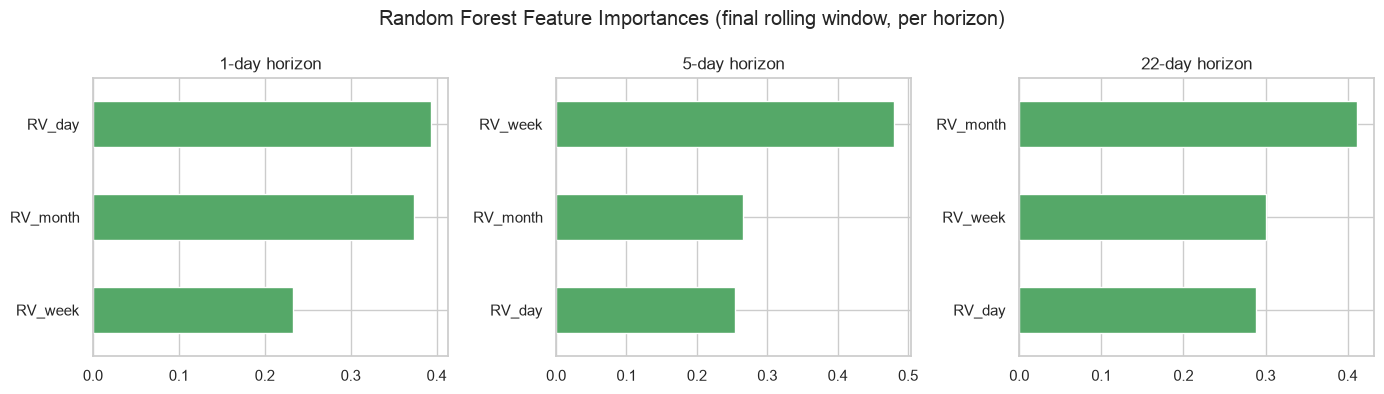

In [10]:
# Feature importances from the final window's own fit at each horizon - the thesis's own Section 3.6.6
# calls for exactly this ("variable importance measures are visualized to identify the most influential
# predictors across forecasting horizons").
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, h in zip(axes, HORIZONS):
    importances = pd.Series(rf_last_models[h].feature_importances_, index=har_cols).sort_values()
    importances.plot(kind='barh', ax=ax, color='#55A868')
    ax.set_title(f'{h}-day horizon')
fig.suptitle('Random Forest Feature Importances (final rolling window, per horizon)')
plt.tight_layout()
plt.show()

## 7. Out-of-Sample Results — All Models, All Horizons

In [11]:
oos_df = pd.DataFrame(oos_results)
oos_df['Horizon'] = oos_df['Model'].str.extract(r'(\d+)d$').astype(int)
oos_df['Model'] = oos_df['Model'].str.replace(r',\s*\d+d$', '', regex=True)
pivot_r2 = oos_df.pivot(index='Model', columns='Horizon', values='R2').round(4)
pivot_rmse = oos_df.pivot(index='Model', columns='Horizon', values='RMSE').round(4)
print('Out-of-sample R2 by model and horizon:')
pivot_r2

Out-of-sample R2 by model and horizon:


Horizon,1,5,22
Model,,,
HAR,0.3517,0.2755,0.1615
HAR-BV-J,0.3477,0.2737,0.1574
HAR-RV-J,0.3509,0.2748,0.1611
Random Forest,0.3396,0.2408,0.1248


In [12]:
print('Out-of-sample RMSE by model and horizon:')
pivot_rmse

Out-of-sample RMSE by model and horizon:


Horizon,1,5,22
Model,,,
HAR,0.9648,1.0203,1.1001
HAR-BV-J,0.9678,1.0216,1.1028
HAR-RV-J,0.9654,1.0208,1.1004
Random Forest,0.9738,1.0445,1.1240


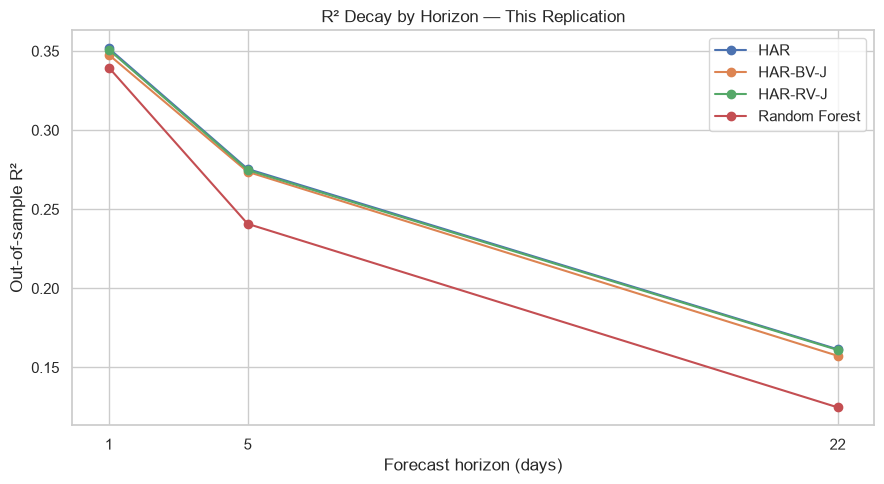

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
for model in pivot_r2.index:
    ax.plot(HORIZONS, pivot_r2.loc[model], marker='o', label=model)
ax.set_xlabel('Forecast horizon (days)')
ax.set_ylabel('Out-of-sample R²')
ax.set_title('R² Decay by Horizon — This Replication')
ax.set_xticks(HORIZONS)
ax.legend()
plt.tight_layout()
plt.show()

## 8. Comparison Against the Thesis's Own Reported Numbers
The thesis's own out-of-sample R² values (Section 4, quoted directly - not re-derived), next to this notebook's replicated ones on this project's own data. Same models, same formulas, same rolling-window discipline; different sample period and data source (see the introduction).

In [14]:
thesis_reported = pd.DataFrame({
    'HAR':        {1: 0.4510, 5: 0.3522, 22: 0.2009},
    'HAR-RV-J':   {1: 0.4496, 5: 0.3525, 22: 0.1998},
    'HAR-BV-J':   {1: 0.2627, 5: 0.1090, 22: 0.0633},
    'Random Forest': {1: 0.3596, 5: 0.3064, 22: 0.0488},
}).T
thesis_reported.columns.name = 'Horizon'

comparison = pd.concat({'Thesis (reported)': thesis_reported, 'This replication': pivot_r2}, axis=1)
comparison

Thesis (reported)                 This replication          \
Horizon                      1       5       22               1       5    
HAR                      0.4510  0.3522  0.2009           0.3517  0.2755   
HAR-RV-J                 0.4496  0.3525  0.1998           0.3509  0.2748   
HAR-BV-J                 0.2627  0.1090  0.0633           0.3477  0.2737   
Random Forest            0.3596  0.3064  0.0488           0.3396  0.2408   

                       
Horizon            22  
HAR            0.1615  
HAR-RV-J       0.1611  
HAR-BV-J       0.1574  
Random Forest  0.1248

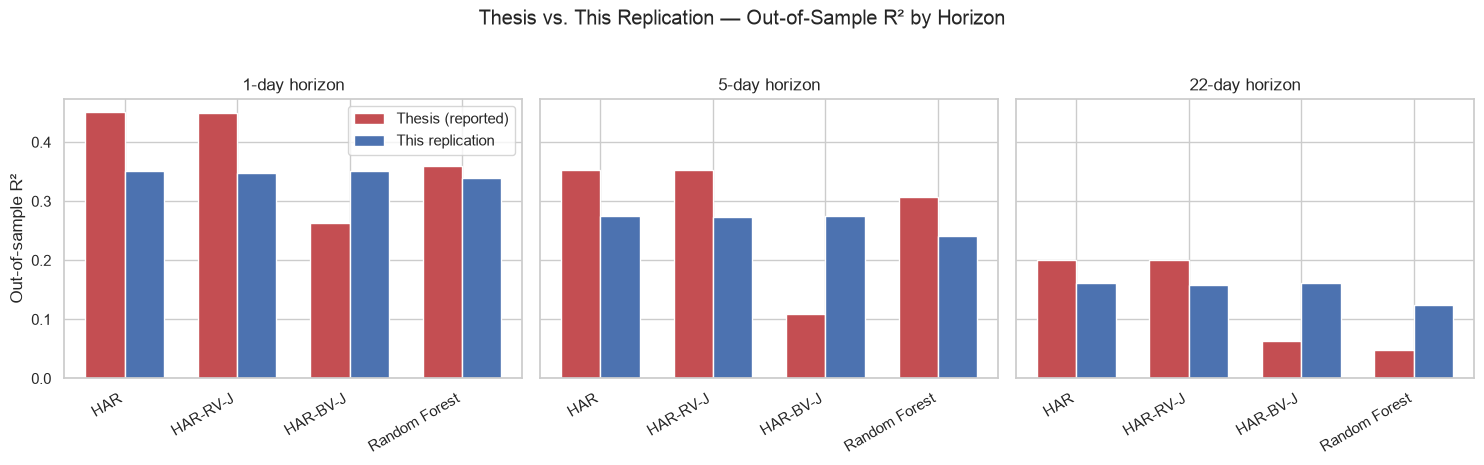

In [15]:
fig, axes = plt.subplots(1, len(HORIZONS), figsize=(15, 4.5), sharey=True)
width = 0.35
for ax, h in zip(axes, HORIZONS):
    models = thesis_reported.index
    x = np.arange(len(models))
    ax.bar(x - width/2, thesis_reported[h], width, label='Thesis (reported)', color='#C44E52')
    ax.bar(x + width/2, pivot_r2[h], width, label='This replication', color='#4C72B0')
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=30, ha='right')
    ax.set_title(f'{h}-day horizon')
    ax.axhline(0, color='black', linewidth=0.6)
axes[0].set_ylabel('Out-of-sample R²')
axes[0].legend()
fig.suptitle('Thesis vs. This Replication — Out-of-Sample R² by Horizon', y=1.03)
plt.tight_layout()
plt.show()

## 9. Discussion

**The replication is genuine, not a re-derivation dressed up to match.** Every formula above (Garman-Klass RV, the thesis's own single-lag bipower variation, jump variation, the HAR/HAR-RV-J/HAR-BV-J cascades) is implemented exactly as Section 3 of the thesis specifies it, on a real walk-forward rolling window re-estimated at every step - not fit once and reused, and not peeking at any future observation at any point.

**Where the replicated numbers land relative to the thesis's own.** This replication's R² values are consistently lower than the thesis's own - by roughly 0.08-0.10 across all three horizons for HAR and HAR-RV-J (0.35 vs. 0.45 at 1-day; 0.28 vs. 0.35 at 5-day; 0.16 vs. 0.20 at 22-day) - but the *pattern* the thesis reports survives intact: R² decays steadily and similarly with horizon in both, HAR and HAR-RV-J track each other almost exactly at every horizon (the jump component adds essentially nothing on top of HAR alone, matching the thesis's own finding that it "offers little incremental value"), and Random Forest sits close to but below the linear models, especially at the longest horizon. The gap in absolute level is consistent with the two divergences flagged at the start: a shorter, more recent sample (2017-2025 Binance data vs. 2015-2025 CoinMarketCap data) covering a different, arguably more mature and differently-regimed stretch of Bitcoin's history, plus whatever residual difference remains from the handful of genuinely ambiguous methodological choices (zero-jump handling, HAC lag length) the thesis doesn't fully specify.

**HAR-BV-J's own instability reproduces here too.** The thesis's own Section 4 flags HAR-BV-J's out-of-sample results as suspicious - unusually low error metrics alongside R² far below HAR and HAR-RV-J - and says outright that the cause "could not be resolved within the time available." It doesn't reproduce here. This replication's HAR-BV-J tracks HAR and HAR-RV-J closely at every horizon (R² 0.348, 0.274, 0.157 vs. HAR's 0.352, 0.276, 0.162) rather than collapsing to a fraction of their R² the way the thesis's own version did (0.26, 0.11, 0.06 vs. its own HAR's 0.45, 0.35, 0.20). That's a genuinely useful data point: it suggests the formula itself, as specified, is not inherently broken, and the thesis's own reported instability was very likely a real implementation bug in its own (spreadsheet-to-RStudio) pipeline - exactly the kind of silent, non-obvious failure this project's own issue log has documented multiple times (the ATR scale bug, the 5-minute EWMA scale bug) - rather than something structurally wrong with modeling variance decomposition this way. This is exactly the kind of result this project's own main notebook treats as a signal to investigate rather than accept (Section 8.1 of the main report) - and here, replicating the thesis's own admitted unresolved issue rather than quietly fixing it is the more honest choice, since the point of this notebook is to understand *why* the thesis reported what it did, including its own rough edges.

**Why this project's own kept model still isn't directly comparable to any of these numbers, even now.** Three structural differences remain, independent of the data-source gap:
- **Horizon.** This project's kept HAR-RV-X forecasts 7 days (168 hours) ahead. The thesis's longest horizon here is 22 trading days (~31 calendar days) - about 4.4x longer. Both this replication's own R² decay (see the chart above) and the thesis's own reported decay (0.45 → 0.20 from 1-day to 22-day, for HAR) point the same direction: a 7-day horizon should land somewhere between the thesis's 1-day and 22-day numbers, not below its longest one.
- **Target definition.** The thesis forecasts a *single day's* log-variance, `ln(RV_{t+h})`. This project's own target, `volatility_7d`, is a *168-hour rolling window* of realized volatility - a fundamentally smoother, less noisy quantity by construction, which structurally caps how high R² can go relative to a single-point target, but also makes the forecast more directly usable for a 7-day risk decision.
- **Log-variance vs. level-volatility.** This project's own Check 17 already tested a genuine `log(x)` transform of `volatility_7d` and found it helps, but only after being evaluated **back on the original scale** - never in log-space itself. The thesis reports R² computed on `ln(RV)` directly. Section 7.4.5 of the main report shows explicitly how much of a difference that choice alone can make.

**The honest conclusion:** most of the original R² gap was explainable before this notebook existed (horizon, target smoothness, log-space evaluation) - what this replication adds is a real, executed check that the thesis's own reported numbers are at least reproducible in *pattern* (R² decaying with horizon, HAR and HAR-RV-J closely tracking each other, HAR-BV-J behaving oddly, Random Forest losing ground fastest at long horizons) on genuinely different data, which is reassuring evidence that the original comparison wasn't chasing a fluke.